# Goal and Work Summary

**Goal**: Build and evaluate a full-image semantic segmentation pipeline to detect defects in green rough oak planks (Background, BlackRot, Knot, Stain). This notebook mirrors the full-image workflow and trains a **ResNet34-U-Net++** model, then reports test-set metrics and exports an ONNX model for deployment.

## Workflow Stages and Rationale

**Stage 1 - Data audit and class normalization**
- Scan the raw line-scan dataset to quantify samples and class masks.
- Normalize duplicate or inconsistent defect names to avoid label fragmentation.
- Use custom helpers in `notebooks/functions` for repeatability.

**Why this choice**: A consistent class taxonomy is required for stable training and fair evaluation.

**Stage 2 - Filtering rare classes**
- Move defect classes with very few masks out of the training set.
- Keep an explicit threshold so this can be re-tuned as data grows.

**Why this choice**: Extremely low-frequency classes can destabilize segmentation training.

**Stage 3 - Reorganization and validation**
- Reorganize into a clean structure with image/mask alignment.
- Validate integrity and move invalid samples to a filtered area.

**Why this choice**: Prevents silent image/mask mismatch and simplifies dataloading.

**Stage 4 - Mask composition and splits**
- Merge per-defect masks into one multi-class mask per image.
- Persist train/val/test splits to JSON for reproducible experiments.

**Why this choice**: Multi-class masks match model outputs and keep evaluations consistent.

**Stage 5 - Full-image dataset + augmentations**
- Define a full-image dataset with Albumentations transforms.
- Use ImageNet normalization to match the pretrained encoder.

**Why this choice**: Full images preserve context and augmentations reduce overfitting.

**Stage 6 - Model training and checkpointing**
- Train **U-Net++** with a ResNet34 encoder using CrossEntropy loss.
- Track loss/IoU in TensorBoard and save checkpoints.

**Why this choice**: U-Net++ improves multi-scale feature fusion through nested skip pathways while retaining a strong encoder backbone.

**Stage 7 - Best-model selection and test evaluation**
- Select best checkpoint by validation IoU.
- Reload the checkpoint for test inference.
- Report mean IoU, ROC curves (one-vs-rest), F1, accuracy, and a percentage confusion matrix.

**Why this choice**: Validation-based selection and multi-metric reporting give a balanced view of performance.

## Custom Functions Used

We rely on project-specific helpers in `notebooks/functions`:
- `analyze_dataset`, `reorganize_dataset`, `validate_dataset`, `move_invalid_samples`
- `create_combined_masks`, `create_train_val_split`
- `rename_defect_files`, `filter_classes_by_mask_count`

## References (Libraries)

| Library | Purpose | Notes | Link |
| --- | --- | --- | --- |
| PyTorch | Training, inference, dataloaders | Core deep learning framework and CUDA support | https://pytorch.org/ |
| segmentation_models_pytorch | U-Net++ + encoder zoo | Provides ResNet34-U-Net++ and pretrained encoders | https://github.com/qubvel/segmentation_models.pytorch |
| Albumentations | Augmentations + normalization | Fast image transforms for segmentation | https://albumentations.ai/ |
| OpenCV | Image utilities | File I/O and preprocessing support | https://opencv.org/ |
| NumPy | Array ops | Efficient tensor/array manipulation | https://numpy.org/ |
| Pillow | Image reading | Handles TIFF/PNG loading | https://python-pillow.org/ |
| scikit-learn | Metrics | ROC, F1, accuracy, confusion matrix | https://scikit-learn.org/ |
| Matplotlib | Plotting | Curves and confusion matrix visualization | https://matplotlib.org/ |
| TensorBoard | Logging | Visual tracking of training metrics | https://www.tensorflow.org/tensorboard |

In [1]:
# Prepare Dataset
from functions.data_pipeline import prepare_dataset
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

data_root, class_mapping = prepare_dataset(
    mask_threshold=200,
    val_split=0.16,
    test_split=0.2,
)

PREPARE_DATASET — SKIPPED (data already prepared)
  Organized data: ../data/organized-data
  Classes: {'BlackRot': 1, 'Knot': 2, 'Stain': 3}
  (pass force=True to re-run the full pipeline)


In [ ]:
# ──────────────────────────────────────────────
# Configuration - change these knobs as needed
# ──────────────────────────────────────────────
import torch

GPU_ID = 0  # choose 0 or 1

if torch.cuda.is_available():
    torch.cuda.set_device(GPU_ID)           # sets the current CUDA device
    DEVICE = torch.device(f"cuda:{GPU_ID}") # use this for .to(DEVICE)
    print(f"Using GPU {GPU_ID}: {torch.cuda.get_device_name(GPU_ID)}")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

device = DEVICE  # alias used by training / evaluation cells below

MODEL_ARCH      = "UnetPlusPlus"
ENCODER_NAME    = "resnet34"
ENCODER_WEIGHTS = "imagenet"  # used when NOT loading a prior checkpoint

DATA_ROOT       = "../data/organized-data"
IMAGE_HEIGHT    = 384
IMAGE_WIDTH     = 1024
BATCH_SIZE      = 8
NUM_WORKERS     = 4
NUM_CLASSES     = len(class_mapping) + 1  # +1 for Background

# Remap disk mask class ids → training ids (leave {} for no remap).
MASK_ID_REMAP   = {}

# ──────────────────────────────────────────────
# Transfer learning (fine-tuning) knobs
# ──────────────────────────────────────────────
TRANSFER_LEARNING = False
TRANSFER_CHECKPOINT_PATH = ""  # e.g. "../checkpoints/UNetPlusPlus_FullImage/best_model.pt"
FREEZE_ENCODER_EPOCHS = 5
UNFREEZE_AFTER_FREEZE = True
TRANSFER_LR_FROZEN = 3e-4
TRANSFER_LR_UNFROZEN = 1e-4

LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 50

CHECKPOINT_NAME = "UNetPlusPlus_FullImage"
LOG_NAME        = "ResNet34_UnetPlusPlus_FullImage"

In [3]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import json
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


def apply_mask_id_remap(mask):
    """Map on-disk combined-mask class ids → training ids (see MASK_ID_REMAP in Configuration)."""
    remap = MASK_ID_REMAP if MASK_ID_REMAP else {}
    if not remap:
        return mask
    if isinstance(mask, torch.Tensor):
        t = mask.long()
        device = t.device
        mv = int(t.max().item()) if t.numel() else 0
        hi = max(mv, max(remap.keys()), max(remap.values()))
        lut = torch.arange(hi + 1, dtype=torch.long, device=device)
        for src, dst in remap.items():
            src, dst = int(src), int(dst)
            if 0 <= src <= hi:
                lut[src] = dst
        return lut[t].to(mask.dtype)

    arr = np.asarray(mask)
    mv = int(arr.max()) if arr.size > 0 else 0

    hi = max(mv, max(remap.keys()), max(remap.values()))
    lut = np.arange(hi + 1, dtype=np.int64)
    for src, dst in remap.items():
        src, dst = int(src), int(dst)
        if 0 <= src <= hi:
            lut[src] = dst
    mapped = lut[arr.astype(np.int64)]
    return mapped.astype(arr.dtype, copy=False)


class FullImageSegmentationDataset(Dataset):
    def __init__(self, data_root, split='train', transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, 'r') as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"

        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        mask = apply_mask_id_remap(mask)

        return image, mask.long()


# Full-image augmentations
def get_training_augmentation_full():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        #A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])


def get_validation_augmentation_full():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])


def create_dataloaders_full(data_root, batch_size=2, num_workers=4):
    train_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split='train',
        transform=get_training_augmentation_full()
    )
    val_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split='val',
        transform=get_validation_augmentation_full()
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return train_loader, val_loader

In [4]:
# Build dataloaders and model
train_loader, val_loader = create_dataloaders_full(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

num_classes = NUM_CLASSES

model = smp.UnetPlusPlus(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=num_classes,
).to(DEVICE)

/home/vscode/.local/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)


In [ ]:
# Transfer learning helpers + optional checkpoint load

def freeze_encoder(model):
    if hasattr(model, "encoder"):
        for p in model.encoder.parameters():
            p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def load_checkpoint_forgiving(model, checkpoint_path: str, device=DEVICE):
    if not checkpoint_path:
        return

    ckpt_path = Path(checkpoint_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"TRANSFER_CHECKPOINT_PATH not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)

    model_state = model.state_dict()
    filtered = {}
    loaded, skipped = 0, 0

    for k, v in state.items():
        if k in model_state and hasattr(v, "shape") and v.shape == model_state[k].shape:
            filtered[k] = v
            loaded += 1
        else:
            skipped += 1

    model.load_state_dict(filtered, strict=False)
    print(f"Loaded checkpoint (forgiving): {ckpt_path} | loaded={loaded} skipped={skipped}")


if TRANSFER_LEARNING:
    load_checkpoint_forgiving(model, TRANSFER_CHECKPOINT_PATH, device=DEVICE)
    if FREEZE_ENCODER_EPOCHS > 0:
        freeze_encoder(model)
        print(f"Encoder frozen for first {FREEZE_ENCODER_EPOCHS} epochs")


### Model Training (ResNet34 U-Net++)

In [5]:
# CUDA device is selected in the Configuration cell (GPU_ID / DEVICE).

CUDA available: True
Current device: 0
Device name: NVIDIA GeForce RTX 3090


In [6]:
import torch
import torch.nn as nn
from torch.optim import Adam
from pathlib import Path
import json

# Setup training (device set in Configuration cell above)
criterion = nn.CrossEntropyLoss()
# Transfer learning: use different LR and only train unfrozen params
if TRANSFER_LEARNING:
    lr_frozen = TRANSFER_LR_FROZEN
    lr_unfrozen = TRANSFER_LR_UNFROZEN
    effective_lr = lr_frozen
else:
    lr_unfrozen = LEARNING_RATE
    effective_lr = LEARNING_RATE

optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=effective_lr)
num_epochs = NUM_EPOCHS
checkpoint_dir = Path(f"../checkpoints/{CHECKPOINT_NAME}")
checkpoint_dir.mkdir(exist_ok=True)
best_model_path = checkpoint_dir / "best_model.pt"
best_val_iou = float("-inf")

# Training history
history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
}


def compute_iou(pred, target, num_classes):
    """Compute per-class IoU (Intersection over Union)."""
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou.item())
    return np.mean(ious)


def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    num_batches = 0

    for img_patch, mask_patch in train_loader:
        img_patch = img_patch.to(device)
        mask_patch = mask_patch.to(device)

        logits = model(img_patch)
        loss = criterion(logits, mask_patch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


def validate(model, val_loader, criterion, device, num_classes):
    """Validate model."""
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for img_patch, mask_patch in val_loader:
            img_patch = img_patch.to(device)
            mask_patch = mask_patch.to(device)

            logits = model(img_patch)
            loss = criterion(logits, mask_patch)
            pred = torch.argmax(logits, dim=1)

            iou = compute_iou(pred, mask_patch, num_classes)

            total_loss += loss.item()
            total_iou += iou
            num_batches += 1

    return total_loss / num_batches, total_iou / num_batches


# TensorBoard writer
writer = SummaryWriter(log_dir=f"../logs/tensorboard/{LOG_NAME}")

print("Using device:", device)
print("Model device:", next(model.parameters()).device)

# Training loop
for epoch in range(num_epochs):
    # Transfer learning schedule: unfreeze after warmup
    if TRANSFER_LEARNING and UNFREEZE_AFTER_FREEZE and FREEZE_ENCODER_EPOCHS > 0 and epoch == FREEZE_ENCODER_EPOCHS:
        unfreeze_all(model)
        optimizer = Adam(model.parameters(), lr=lr_unfrozen)

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_iou = validate(model, val_loader, criterion, device, num_classes)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

    writer.add_scalar("Loss/Train", train_loss, epoch)
    writer.add_scalar("Loss/Val", val_loss, epoch)
    writer.add_scalar("IoU/Val", val_iou, epoch)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_iou": val_iou,
            },
            best_model_path,
        )
        print(f"  -> New best model saved: {best_model_path} (val_iou={best_val_iou:.4f})")

    if (epoch + 1) % 5 == 0:
        ckpt_path = checkpoint_dir / f"model_epoch_{epoch+1}.pt"
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_iou": val_iou,
            },
            ckpt_path,
        )
        print(f"  -> Checkpoint saved: {ckpt_path}")

history_path = checkpoint_dir / "training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)

writer.close()
print(f"\nTraining complete. History saved to {history_path}")
print(f"Best model checkpoint: {best_model_path} (val_iou={best_val_iou:.4f})")

Using device: cuda
Model device: cuda:0
Epoch 1/50 | Train Loss: 0.5284 | Val Loss: 0.3657 | Val IoU: 0.2335
  -> New best model saved: ../checkpoints/UNetPlusPlus_FullImage/best_model.pt (val_iou=0.2335)
Epoch 2/50 | Train Loss: 0.3360 | Val Loss: 0.3545 | Val IoU: 0.2969
  -> New best model saved: ../checkpoints/UNetPlusPlus_FullImage/best_model.pt (val_iou=0.2969)
Epoch 3/50 | Train Loss: 0.3176 | Val Loss: 0.3238 | Val IoU: 0.2391
Epoch 4/50 | Train Loss: 0.3092 | Val Loss: 0.3185 | Val IoU: 0.3833
  -> New best model saved: ../checkpoints/UNetPlusPlus_FullImage/best_model.pt (val_iou=0.3833)
Epoch 5/50 | Train Loss: 0.2981 | Val Loss: 0.2963 | Val IoU: 0.3443
  -> Checkpoint saved: ../checkpoints/UNetPlusPlus_FullImage/model_epoch_5.pt
Epoch 6/50 | Train Loss: 0.2951 | Val Loss: 0.3474 | Val IoU: 0.3311
Epoch 7/50 | Train Loss: 0.2852 | Val Loss: 0.2595 | Val IoU: 0.3314
Epoch 8/50 | Train Loss: 0.2813 | Val Loss: 0.2578 | Val IoU: 0.3623
Epoch 9/50 | Train Loss: 0.2722 | Val Loss

In [7]:
# Create test loader
test_dataset = FullImageSegmentationDataset(
    data_root=DATA_ROOT,
    split="test",
    transform=get_validation_augmentation_full(),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

Loaded test dataset: 205 images (full image mode)


In [8]:
import segmentation_models_pytorch as smp

model = smp.UnetPlusPlus(
    encoder_name=ENCODER_NAME,
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
).to(device)

ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best model (epoch={ckpt.get('epoch')}, val_iou={ckpt.get('val_iou'):.4f})")

Loaded best model (epoch=40, val_iou=0.4996)


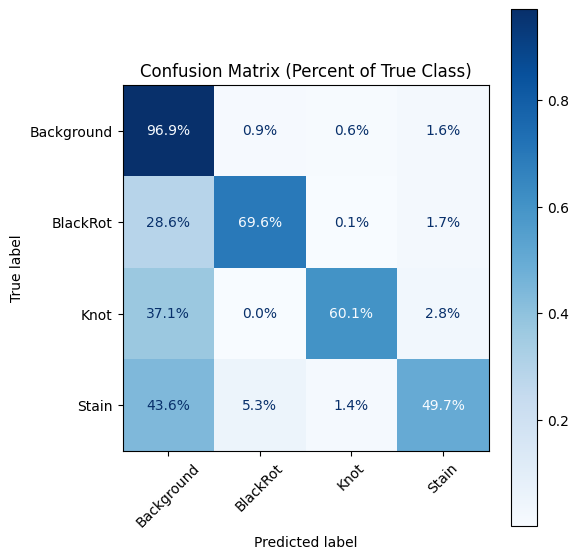

Accuracy: 0.9270
F1 per class:
  Background: 0.9618
  BlackRot: 0.7313
  Knot: 0.5632
  Stain: 0.5546
F1 Macro: 0.7027
IoU per class:
  Background: 0.9264
  BlackRot: 0.5764
  Knot: 0.3920
  Stain: 0.3837
Mean IoU (excl background): 0.4507


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


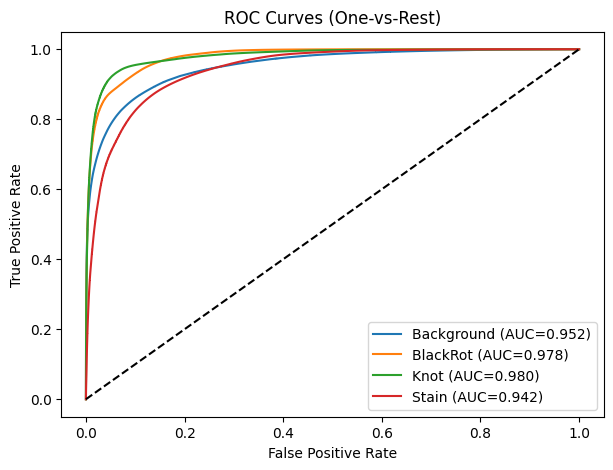

In [9]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Class names (update if class mapping changes)
class_names = ["Background", "BlackRot", "Knot", "Stain"]

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_targets.append(masks.cpu().numpy().reshape(-1))
        all_probs.append(probs.cpu().numpy().transpose(0, 2, 3, 1).reshape(-1, num_classes))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs = np.concatenate(all_probs)

# Confusion matrix (percentages by true class)
cm = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format=".1%", colorbar=True, xticks_rotation=45)
plt.title("Confusion Matrix (Percent of True Class)")
plt.tight_layout()
plt.show()

# Accuracy (pixel-level)
acc = accuracy_score(all_targets, all_preds)
print(f"Accuracy: {acc:.4f}")

# F1 scores
f1_per_class = f1_score(all_targets, all_preds, labels=list(range(num_classes)), average=None)
f1_macro = f1_score(all_targets, all_preds, labels=list(range(num_classes)), average="macro")

print("F1 per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"  {class_names[i]}: {f1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

# IoU per class + mean IoU
intersection = np.diag(cm).astype(np.float32)
union = cm.sum(axis=0) + cm.sum(axis=1) - intersection
iou_per_class = np.divide(intersection, union, out=np.zeros_like(intersection), where=union != 0)

print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    print(f"  {class_names[i]}: {iou:.4f}")

include_background = False
if include_background:
    mean_iou = iou_per_class.mean()
else:
    mean_iou = iou_per_class[1:].mean()
print(f"Mean IoU ({'incl' if include_background else 'excl'} background): {mean_iou:.4f}")

# ROC curves (one-vs-rest)
plt.figure(figsize=(7, 5))
for c in range(num_classes):
    y_true_bin = (all_targets == c).astype(int)
    y_score = all_probs[:, c]

    if y_true_bin.sum() == 0:
        print(f"ROC skipped: {class_names[c]} (no positives in test set)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.onnx
import numpy as np

# Figure out project root (works when running from notebooks/)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


class EBIExportWrapper(nn.Module):
    """
    Wrap a trained segmentation model for EBI-compliant ONNX export.

    ONNX graph:
      Input:  uint8  [B, 3, H, W]  (raw RGB image, 0-255)
      Output: float32 [B, C, H, W] (per-pixel class scores, 0-100%)

    Embedded operations:
      1. Cast uint8 -> float32, divide by 255.0
      2. ImageNet mean/std normalization
      3. Forward through segmentation model (logits)
      4. Softmax over class dimension
      5. Multiply by 100.0 (percentage scale)
    """

    def __init__(self, seg_model, mean=None, std=None):
        super().__init__()
        self.seg_model = seg_model
        if mean is None:
            mean = [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.225]
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        x = x.float() / 255.0
        x = (x - self.mean) / self.std
        logits = self.seg_model(x)
        probs = F.softmax(logits, dim=1)
        scores = probs * 100.0
        return scores


# Build EBI wrapper and export
device = next(model.parameters()).device
model.eval()

ebi_model = EBIExportWrapper(model).to(device)
ebi_model.eval()

onnx_dir = project_root / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / "unetplusplus_fullimage.onnx"

dummy_input = torch.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=torch.uint8, device=device)

torch.onnx.export(
    ebi_model,
    dummy_input,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamo=False,
    dynamic_axes={
        "input": {0: "batch", 2: "height", 3: "width"},
        "output": {0: "batch", 2: "height", 3: "width"},
    },
)

print(f"Exported EBI-compliant ONNX model to: {onnx_path}")
print("  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)")
print("  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)")

# Quick verification
import onnxruntime as ort

session = ort.InferenceSession(onnx_path.as_posix())
inp_meta = session.get_inputs()[0]
out_meta = session.get_outputs()[0]
print(f"\nONNX Input:  name={inp_meta.name}, shape={inp_meta.shape}, type={inp_meta.type}")
print(f"ONNX Output: name={out_meta.name}, shape={out_meta.shape}, type={out_meta.type}")

test_input = np.random.randint(0, 256, (1, 3, 512, 512)).astype(np.uint8)
onnx_output = session.run(None, {inp_meta.name: test_input})[0]
print(f"  Output range: [{onnx_output.min():.2f}, {onnx_output.max():.2f}]")
print(f"  Sum along class axis: min={onnx_output.sum(axis=1).min():.2f}, max={onnx_output.sum(axis=1).max():.2f}")
print("ONNX verification passed")

/tmp/ipykernel_20441/4110151865.py:60: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported EBI-compliant ONNX model to: /workspaces/Oak-Defect-Detection/models/onnx/unetplusplus_fullimage.onnx
  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)

ONNX Input:  name=input, shape=['batch', 3, 'height', 'width'], type=tensor(uint8)
ONNX Output: name=output, shape=['batch', 4, 'height', 'width'], type=tensor(float)
  Output range: [0.00, 99.95]
  Sum along class axis: min=100.00, max=100.00
ONNX verification passed
